# Project 02: Titanic Survival Prediction (Classification)

## Overview
This project involves building a Binary Classification model to predict passenger survival on the Titanic. Unlike regression, we are predicting a discrete category (0 = Deceased, 1 = Survived).

## Dataset
We are using the Titanic dataset from the Seaborn library, which includes passenger demographics (age, sex, class) and travel information.

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Load the built-in titanic dataset from Seaborn
df = sns.load_dataset('titanic')

# Let's see the 'Target' ( Survived ) and the 'Features' ( class, sex, age, etc)
display(df.head())

# Check for the 'Big Hurdle' : Missing Data
print("\n--- Missing Values ---")
print(df.isnull().sum())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- Missing Values ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## Step 1: Data Cleaning & Feature Engineering
Real-world data is messy. In this step, we:
1. **Handled Missing Values:** Imputed missing 'age' with the median and 'embarked' with the mode.
2. **Feature Selection:** Dropped columns with too much missing data (deck) or redundant info.
3. **Encoding:** Converted categorical text ('sex', 'embarked') into numerical values using mapping and One-Hot Encoding.

In [2]:
# 1. Drop 'deck' because it's mostly missing values
# We also drop 'embark_town' (redundant with 'embarked'), 'alive' (same as 'survived'), 
# and 'who/adult_male' (redundant with 'sex' and 'pclass')

df = df.drop(columns = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'])

# 2. Fill missing 'age' values with the Median age (it's safer than the mean against outliers)
df['age'] = df['age'].fillna(df['age'].median())

# 3. Fill the 2 missing 'embarked' values with the most common port ('S')
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print("Missing Values after Cleaning: ")
print(df.isnull().sum())


Missing Values after Cleaning: 
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


In [4]:
# Convert 'sex' into 0 and 1 (Female = 0, Male = 1 is standard, but check your output)
df['sex'] = df['sex'].map({'female':0 , 'male': 1})

# One-Hot Encoding for 'embarked' (Turns 'S', 'C', 'Q' into separate 0/1 columns)
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

display(df.head())

,survived,pclass,sex,age,sibsp,parch,fare,alone,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,False,True
1,1,1,0,38.0,1,0,71.2833,False,False,False
2,1,3,0,26.0,0,0,7.9250,True,False,True
3,1,1,0,35.0,1,0,53.1000,False,False,True
4,0,3,1,35.0,0,0,8.0500,True,False,True


In [5]:
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df.drop('survived', axis=1)
y = df['survived']

# Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

print(f"Training Set Size: {len(X_train)}")
print(f"Testing Set Size : {len(X_test)}")

Training Set Size: 712
Testing Set Size : 179


## Step 2: Feature Scaling
Logistic Regression is sensitive to the scale of input features. We used `StandardScaler` to normalize features like 'age' and 'fare' so they have a mean of 0 and a standard deviation of 1. This ensures the model converges correctly.

In [6]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize (increase max_iter to ensure the model converges)
clf = LogisticRegression(max_iter=200)

# 2. Train
clf.fit(X_train, y_train)

print("Classification Model Trained!")

Classification Model Trained!


/Users/shashankjaji/Documents/Data Analytics_2026/DataScience-Mini-Projects/classification_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit the scaler on the TRAINING data only and transform it
# (We don't want information from the test set 'leaking' into our training)
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the testng data using the SAME scaler
X_test_scaled = scaler.transform(X_test)

# 4. Retain the model on the SCALED Data
clf = LogisticRegression() # Default max_iter=100 is usually enough now!
clf.fit(X_train_scaled, y_train)

print("Model trained successfully with scaled data! ")

Model trained successfully with scaled data! 


## Step 3: Model Training & Evaluation
We trained a **Logistic Regression** model and evaluated it using a **Confusion Matrix** and a **Classification Report**.

### Key Results:
- **Accuracy:** 80%
- **F1-Score (Survived):** 0.75

Overall Accuracy: 79.89%


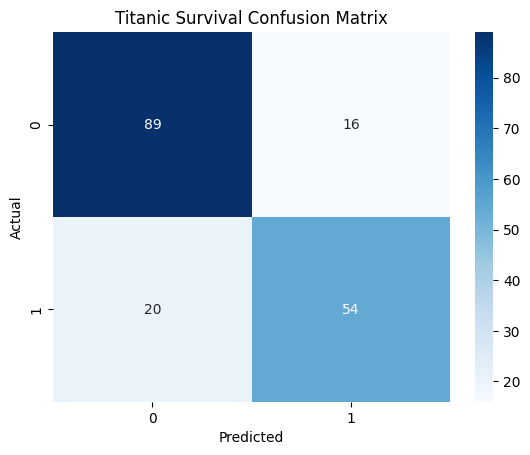


Classification Report: 
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [9]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Make Predictions
y_pred = clf.predict(X_test_scaled)

# 2. Check the Accuracy 
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt = 'd', cmap = 'Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Titanic Survival Confusion Matrix')
plt.show()

# 4. Detailed Report (Precision, Recall, F1-score)
print("\nClassification Report: ")
print(classification_report(y_test, y_pred))
